# EDA — Distribusi Transaksi Harian & Mingguan per Kategori per User

Analisis distribusi:
1. **Nominal transaksi harian** per kategori (aggregat seluruh user)
2. **Jumlah transaksi per minggu** per kategori per user

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 10

DATA_DIR = '../../../data/new'

df_trx = pd.read_csv(f'{DATA_DIR}/df_transaksi.csv', parse_dates=['timestamp'])
df_nas = pd.read_csv(f'{DATA_DIR}/df_nasabah.csv')

print(f'Transaksi : {df_trx.shape}')
print(f'Nasabah   : {df_nas.shape}')
df_trx.head(3)

Transaksi : (150274, 14)
Nasabah   : (500, 11)


,id_transaksi,id_user,timestamp,tipe_mutasi,deskripsi_mutasi,catatan_mutasi,mcc,nominal,sisa_saldo,kategori_besar,kategori_detail,label_anomali,gt_kategori_besar,gt_kategori_detail
0,TRX-12400,USR-133,2026-01-01 00:00:00,Debit,YOSHINOYA,-,5812,52604.72,4011210.57,Wants,F&B dan Nongkrong,0,Wants,F&B dan Nongkrong
1,TRX-14568,USR-048,2026-01-01 00:06:00,Debit,MCDONALD'S,-,5814,59101.61,3580268.10,Wants,F&B dan Nongkrong,0,Wants,F&B dan Nongkrong
2,TRX-13000,USR-455,2026-01-01 00:07:00,Debit,INDOMIE REBUS WARUNG,-,5814,8558.93,23578441.07,Wants,F&B dan Nongkrong,0,Needs,F&B dan Nongkrong


In [2]:
df = df_trx.copy()

df['tanggal']    = df['timestamp'].dt.date
df['minggu_num'] = df['timestamp'].dt.isocalendar().week.astype(int)
df['hari_nama']  = df['timestamp'].dt.day_name()

df = df.dropna(subset=['kategori_detail', 'kategori_besar'])
df_debit = df[df['tipe_mutasi'] == 'Debit'].copy()

KATEGORI_ORDER = sorted(df['kategori_detail'].unique())
print('Kategori Detail:', KATEGORI_ORDER)
print('Rentang tanggal:', df['tanggal'].min(), '-', df['tanggal'].max())

Kategori Detail: ['Belanja Online & Fashion', 'F&B dan Nongkrong', 'Groceries & Kebutuhan Pokok', 'Hiburan & Langganan', 'Investasi & Finansial', 'Kesehatan & Perawatan Diri', 'Pemasukan Tambahan', 'Pendapatan Bulanan', 'Produktivitas & Digital', 'Tagihan & Utilitas', 'Transfer P2P', 'Transportasi']
Rentang tanggal: 2026-01-01 - 2026-03-31


---
## 1. Distribusi Nominal Harian per Kategori (seluruh user)

Setiap titik = total nominal transaksi satu user dalam satu hari untuk satu kategori (Debit).

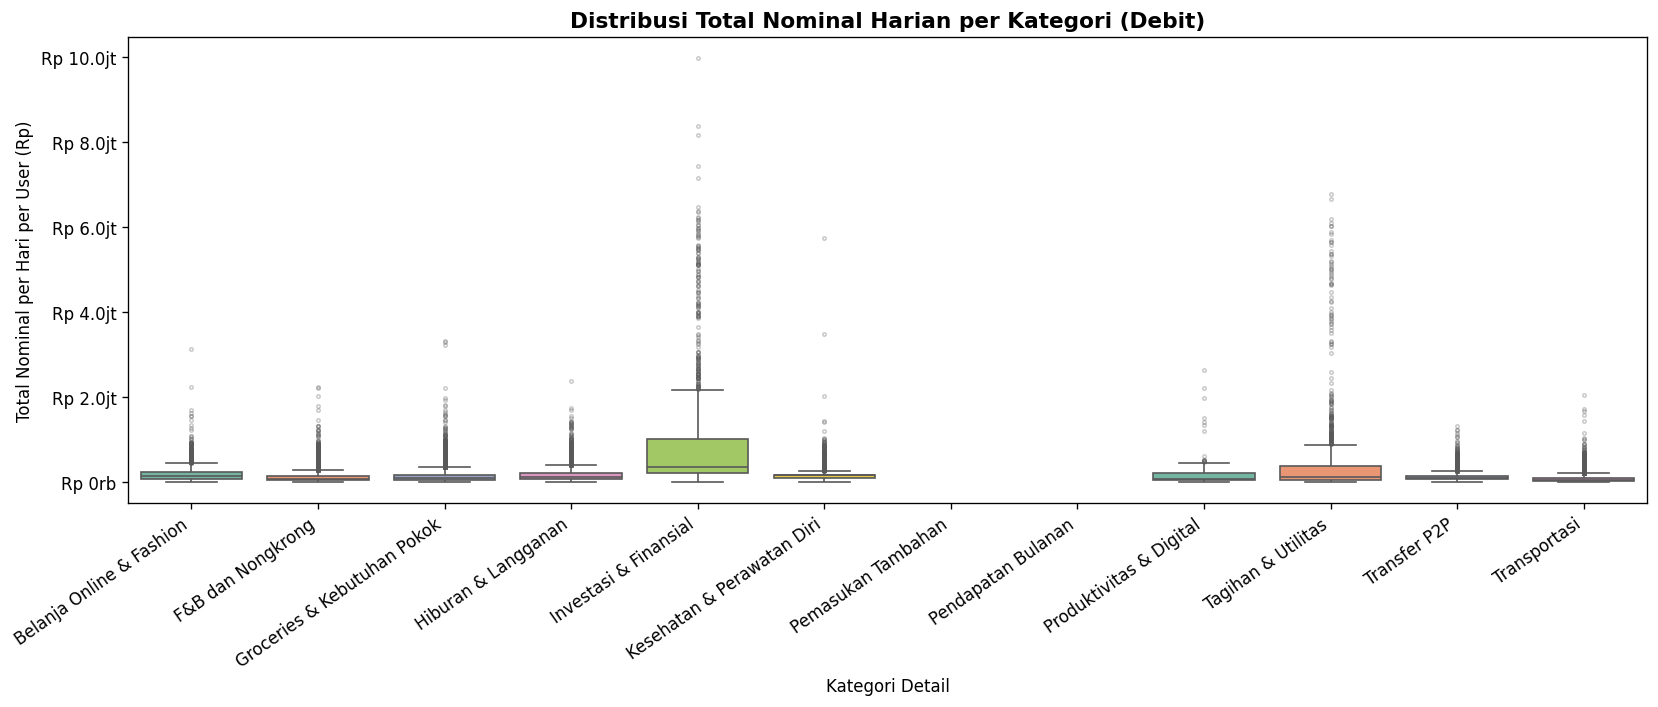


Statistik Nominal Harian per Kategori (Debit):


,count,mean,std,min,25%,50%,75%,95%,max
kategori_detail,,,,,,,,,
Belanja Online & Fashion,3671.0,174949.0,171956.0,2000.0,70037.0,133595.0,221157.0,481664.0,3118840.0
F&B dan Nongkrong,21590.0,104887.0,120208.0,2000.0,31445.0,68274.0,132222.0,332598.0,2232483.0
Groceries & Kebutuhan Pokok,13776.0,128588.0,153027.0,2000.0,40922.0,79546.0,163783.0,401206.0,3315542.0
Hiburan & Langganan,8598.0,158411.0,151589.0,2000.0,59000.0,113900.0,193009.0,430933.0,2359072.0
Investasi & Finansial,2140.0,804910.0,1127986.0,43.0,208048.0,348927.0,996388.0,2919659.0,9970033.0
Kesehatan & Perawatan Diri,3670.0,154844.0,170590.0,2000.0,77537.0,150000.0,150000.0,389556.0,5745042.0
Produktivitas & Digital,1404.0,114480.0,156668.0,3306.0,35702.0,70000.0,200000.0,340403.0,2638743.0
Tagihan & Utilitas,1122.0,503097.0,1060209.0,2000.0,41561.0,106965.0,378250.0,2427223.0,6772211.0
Transfer P2P,6212.0,110637.0,94899.0,2000.0,56639.0,87384.0,135571.0,257414.0,1315156.0


In [3]:
daily_user_kat = (
    df_debit
    .groupby(['id_user', 'tanggal', 'kategori_detail'])['nominal']
    .sum()
    .reset_index(name='total_nominal')
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=daily_user_kat,
    x='kategori_detail',
    y='total_nominal',
    order=KATEGORI_ORDER,
    palette='Set2',
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)

ax.set_title('Distribusi Total Nominal Harian per Kategori (Debit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Detail')
ax.set_ylabel('Total Nominal per Hari per User (Rp)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'Rp {x/1e6:.1f}jt' if x >= 1e6 else f'Rp {x/1e3:.0f}rb'
))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('\nStatistik Nominal Harian per Kategori (Debit):')
daily_user_kat.groupby('kategori_detail')['total_nominal'].describe(
    percentiles=[.25, .5, .75, .95]
).round(0)

---
## 2. Rata-rata Nominal Harian per Kategori — per Hari dalam Seminggu

Heatmap pola pengeluaran berdasarkan hari (Senin–Minggu).

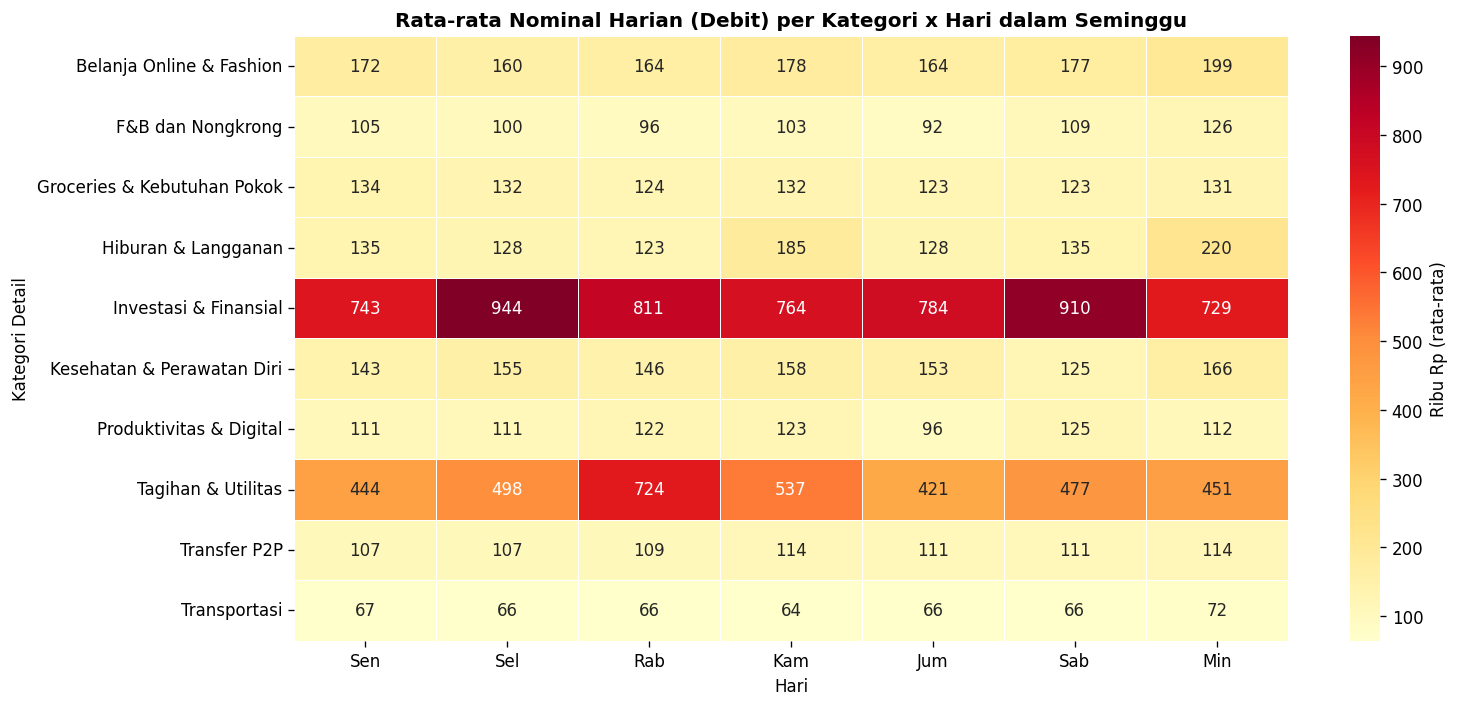

In [4]:
daily_user_kat['hari_nama'] = pd.to_datetime(daily_user_kat['tanggal']).dt.day_name()

DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
DAY_LABEL = ['Sen', 'Sel', 'Rab', 'Kam', 'Jum', 'Sab', 'Min']

pivot_harian = (
    daily_user_kat
    .groupby(['kategori_detail', 'hari_nama'])['total_nominal']
    .mean()
    .unstack('hari_nama')
    .reindex(columns=DAY_ORDER)
)
pivot_harian.columns = DAY_LABEL

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    pivot_harian / 1e3,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Ribu Rp (rata-rata)'},
    ax=ax
)
ax.set_title('Rata-rata Nominal Harian (Debit) per Kategori x Hari dalam Seminggu', fontsize=12, fontweight='bold')
ax.set_xlabel('Hari')
ax.set_ylabel('Kategori Detail')
plt.tight_layout()
plt.show()

---
## 3. Distribusi Jumlah Transaksi per Minggu per Kategori per User

Setiap titik = jumlah transaksi satu user dalam satu minggu untuk satu kategori.

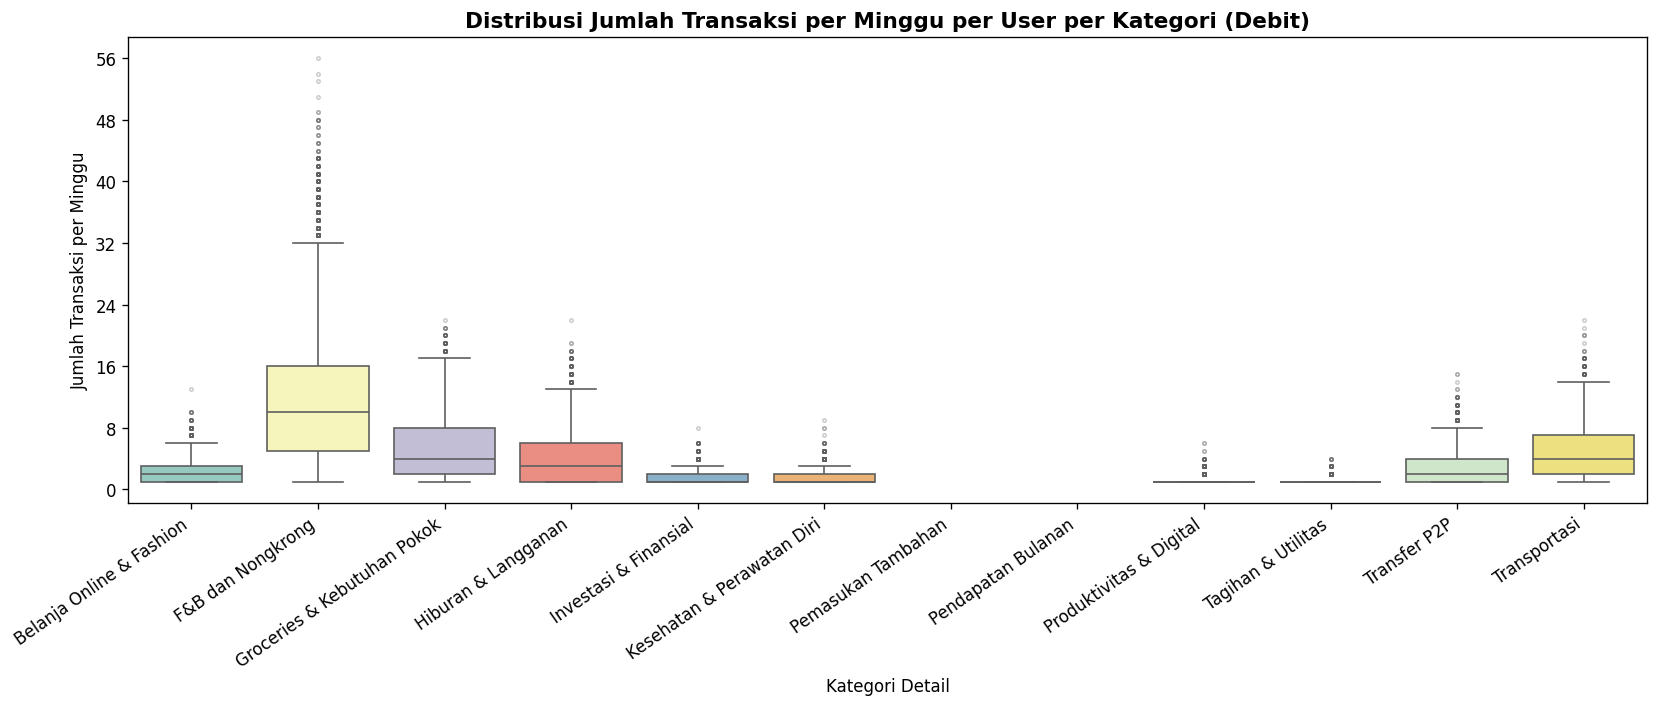


Statistik Jumlah Transaksi per Minggu per Kategori:


,count,mean,std,min,25%,50%,75%,95%,max
kategori_detail,,,,,,,,,
Belanja Online & Fashion,1955.0,2.38,1.79,1.0,1.0,2.0,3.0,6.0,13.0
F&B dan Nongkrong,5214.0,12.14,9.60,1.0,5.0,10.0,16.0,33.0,56.0
Groceries & Kebutuhan Pokok,4463.0,5.27,4.27,1.0,2.0,4.0,8.0,14.0,22.0
Hiburan & Langganan,3557.0,4.12,3.59,1.0,1.0,3.0,6.0,12.0,22.0
Investasi & Finansial,1530.0,1.52,0.95,1.0,1.0,1.0,2.0,4.0,8.0
Kesehatan & Perawatan Diri,2726.0,1.52,0.89,1.0,1.0,1.0,2.0,3.0,9.0
Produktivitas & Digital,1144.0,1.30,0.63,1.0,1.0,1.0,1.0,3.0,6.0
Tagihan & Utilitas,965.0,1.21,0.49,1.0,1.0,1.0,1.0,2.0,4.0
Transfer P2P,2843.0,3.00,2.28,1.0,1.0,2.0,4.0,7.0,15.0


In [5]:
# Aggregasi: hitung transaksi per user per minggu per kategori
weekly_user_kat = (
    df_debit
    .groupby(['id_user', 'minggu_num', 'kategori_detail'])['id_transaksi']
    .count()
    .reset_index(name='jumlah_trx')
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=weekly_user_kat,
    x='kategori_detail',
    y='jumlah_trx',
    order=KATEGORI_ORDER,
    palette='Set3',
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)

ax.set_title('Distribusi Jumlah Transaksi per Minggu per User per Kategori (Debit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Detail')
ax.set_ylabel('Jumlah Transaksi per Minggu')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('\nStatistik Jumlah Transaksi per Minggu per Kategori:')
weekly_user_kat.groupby('kategori_detail')['jumlah_trx'].describe(
    percentiles=[.25, .5, .75, .95]
).round(2)

---
## 4. Heatmap — Rata-rata Jumlah Transaksi per Minggu (Kategori x Minggu ke-N)

Tren mingguan masing-masing kategori sepanjang 3 bulan data.

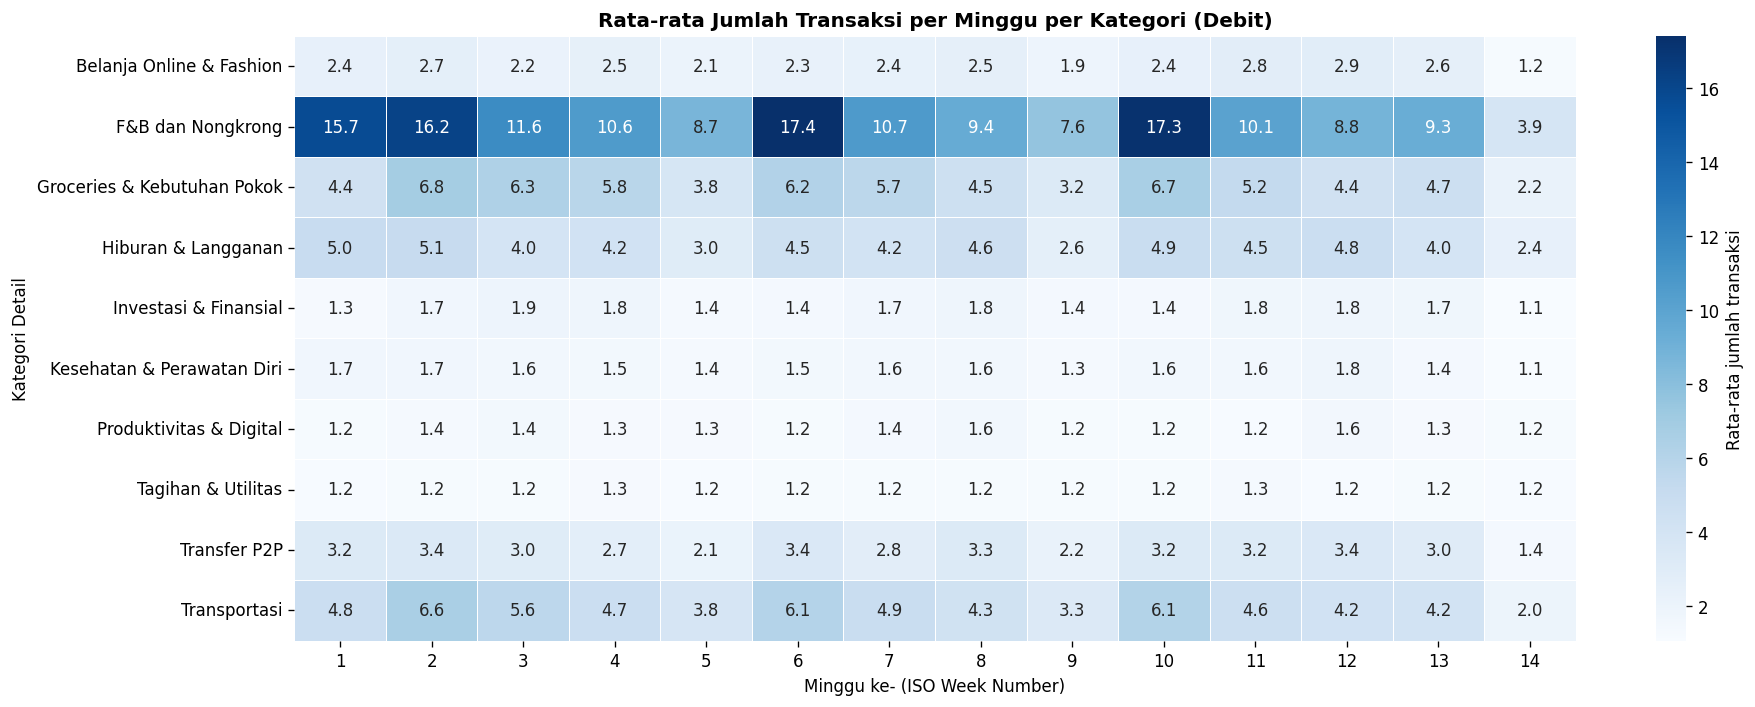

In [6]:
pivot_weekly = (
    weekly_user_kat
    .groupby(['kategori_detail', 'minggu_num'])['jumlah_trx']
    .mean()
    .unstack('minggu_num')
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    pivot_weekly,
    annot=True, fmt='.1f', cmap='Blues',
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Rata-rata jumlah transaksi'},
    ax=ax
)
ax.set_title('Rata-rata Jumlah Transaksi per Minggu per Kategori (Debit)', fontsize=12, fontweight='bold')
ax.set_xlabel('Minggu ke- (ISO Week Number)')
ax.set_ylabel('Kategori Detail')
plt.tight_layout()
plt.show()

---
## 5. Nominal Mingguan per Kategori — Tren & Distribusi Antar-User

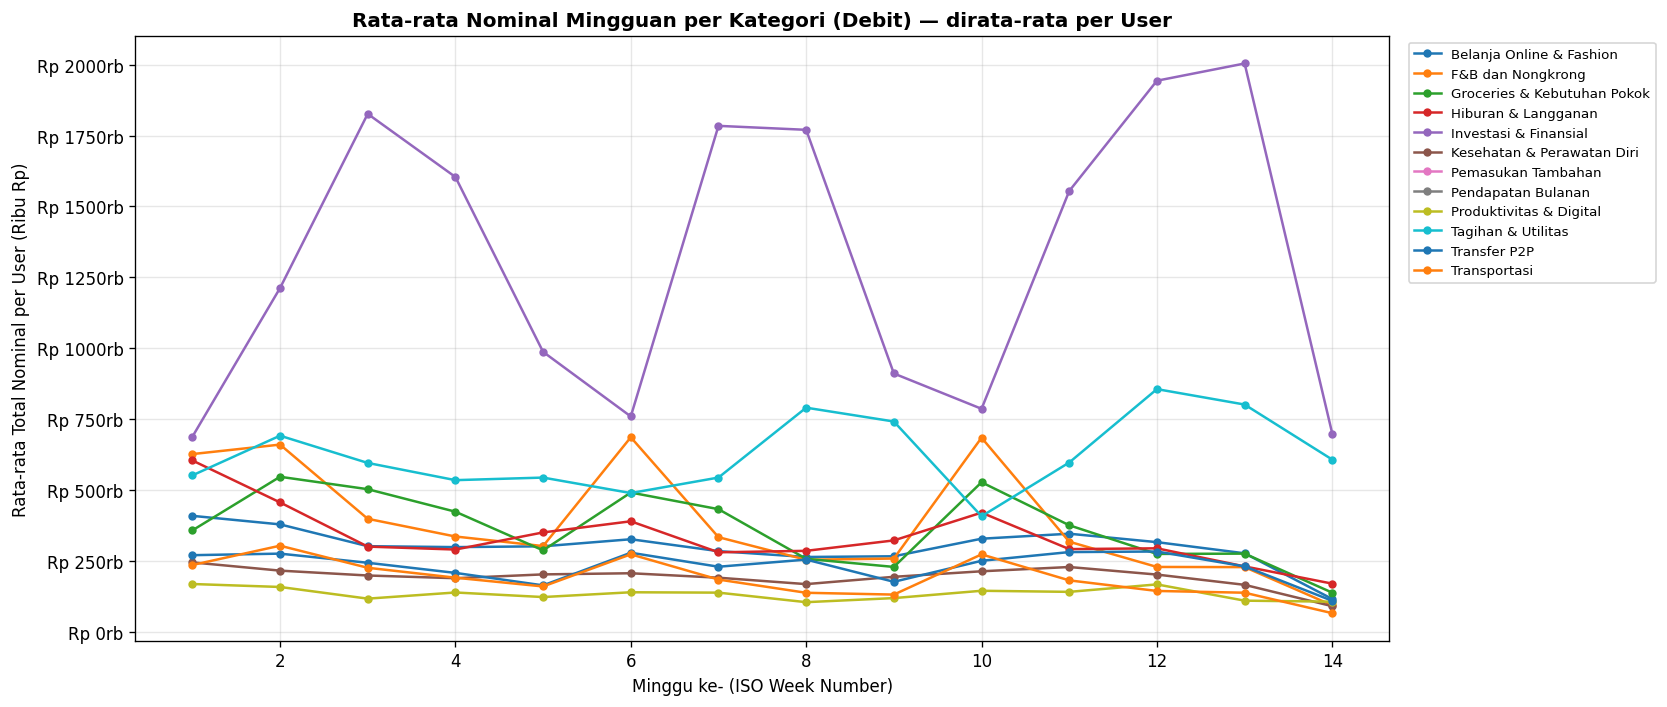

In [7]:
weekly_nominal = (
    df_debit
    .groupby(['id_user', 'minggu_num', 'kategori_detail'])['nominal']
    .sum()
    .reset_index(name='total_nominal')
)

agg_weekly = (
    weekly_nominal
    .groupby(['minggu_num', 'kategori_detail'])['total_nominal']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

palette = sns.color_palette('tab10', n_colors=len(KATEGORI_ORDER))
for i, kat in enumerate(KATEGORI_ORDER):
    subset = agg_weekly[agg_weekly['kategori_detail'] == kat]
    ax.plot(subset['minggu_num'], subset['total_nominal'] / 1e3,
            marker='o', markersize=4, label=kat, color=palette[i])

ax.set_title('Rata-rata Nominal Mingguan per Kategori (Debit) — dirata-rata per User', fontsize=12, fontweight='bold')
ax.set_xlabel('Minggu ke- (ISO Week Number)')
ax.set_ylabel('Rata-rata Total Nominal per User (Ribu Rp)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x:.0f}rb'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

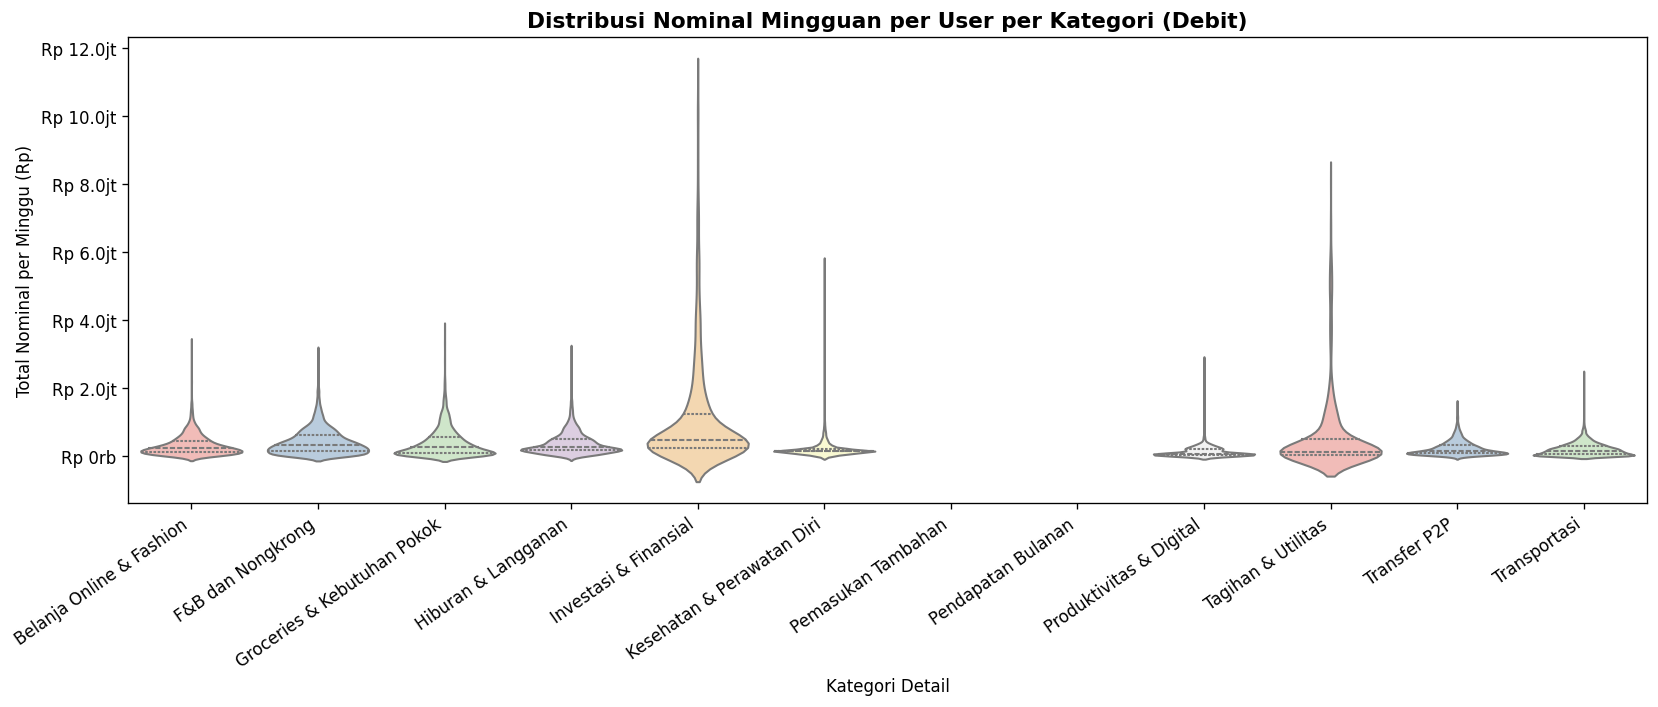

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.violinplot(
    data=weekly_nominal,
    x='kategori_detail',
    y='total_nominal',
    order=KATEGORI_ORDER,
    palette='Pastel1',
    inner='quartile',
    ax=ax
)

ax.set_title('Distribusi Nominal Mingguan per User per Kategori (Debit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Detail')
ax.set_ylabel('Total Nominal per Minggu (Rp)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'Rp {x/1e6:.1f}jt' if x >= 1e6 else f'Rp {x/1e3:.0f}rb'
))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

---
## 6. Rangkuman — Tabel Statistik Mingguan per Kategori

In [9]:
summary_nominal = weekly_nominal.groupby('kategori_detail')['total_nominal'].agg(
    median_nominal = 'median',
    mean_nominal   = 'mean',
    p75_nominal    = lambda x: x.quantile(0.75),
    p95_nominal    = lambda x: x.quantile(0.95),
)

summary_trx = weekly_user_kat.groupby('kategori_detail')['jumlah_trx'].agg(
    median_trx = 'median',
    mean_trx   = 'mean',
    p75_trx    = lambda x: x.quantile(0.75),
    p95_trx    = lambda x: x.quantile(0.95),
)

summary = summary_nominal.join(summary_trx).round(1)
summary.columns = [
    'Median Nominal/Minggu', 'Mean Nominal/Minggu', 'P75 Nominal', 'P95 Nominal',
    'Median Trx/Minggu', 'Mean Trx/Minggu', 'P75 Trx', 'P95 Trx'
]

pd.set_option('display.float_format', '{:,.1f}'.format)
summary

,Median Nominal/Minggu,Mean Nominal/Minggu,P75 Nominal,P95 Nominal,Median Trx/Minggu,Mean Trx/Minggu,P75 Trx,P95 Trx
kategori_detail,,,,,,,,
Belanja Online & Fashion,"237,237.8","328,510.8","455,297.2","893,261.3",2.0,2.4,3.0,6.0
F&B dan Nongkrong,"336,391.4","434,313.5","613,642.9","1,183,631.6",10.0,12.1,16.0,33.0
Groceries & Kebutuhan Pokok,"262,017.2","396,915.5","556,412.5","1,245,278.6",4.0,5.3,8.0,14.0
Hiburan & Langganan,"277,656.8","382,912.0","514,194.4","1,000,150.2",3.0,4.1,6.0,12.0
Investasi & Finansial,"480,499.9","1,125,821.1","1,256,623.6","4,711,469.0",1.0,1.5,2.0,4.0
Kesehatan & Perawatan Diri,"150,000.0","208,465.3","225,539.3","556,065.2",1.0,1.5,2.0,3.0
Produktivitas & Digital,"79,000.0","140,498.8","208,472.0","352,957.6",1.0,1.3,1.0,3.0
Tagihan & Utilitas,"127,761.8","584,947.7","493,880.9","3,457,765.6",1.0,1.2,1.0,2.0
Transfer P2P,"167,716.8","241,743.9","330,157.5","686,105.3",2.0,3.0,4.0,7.0


---
## 7. Rincian per User — Nominal & Jumlah Transaksi per Kategori per Minggu

Tabel pivot per user: baris = kategori, kolom = minggu (sub-kolom: **Nominal** dan **Trx**).

In [10]:
def fmt_nominal(x):
    if pd.isna(x) or x == 0:
        return '-'
    elif x >= 1_000_000:
        return f'Rp {x/1_000_000:.2f}jt'
    return f'Rp {x/1_000:.0f}rb'


def fmt_trx(x):
    if pd.isna(x) or x == 0:
        return '-'
    return str(int(x))


def user_weekly_table(user_id, df_debit):
    df_u = df_debit[df_debit['id_user'] == user_id].copy()

    grp = df_u.groupby(['kategori_detail', 'minggu_num']).agg(
        nominal=('nominal', 'sum'),
        trx=('id_transaksi', 'count')
    ).reset_index()

    weeks = sorted(grp['minggu_num'].unique())

    piv_nominal = grp.pivot(index='kategori_detail', columns='minggu_num', values='nominal').fillna(0)
    piv_trx     = grp.pivot(index='kategori_detail', columns='minggu_num', values='trx').fillna(0)

    frames = []
    for w in weeks:
        col_label = f'Minggu {w}'
        frames.append(piv_nominal[w].rename((col_label, 'Nominal')))
        frames.append(piv_trx[w].rename((col_label, 'Trx')))

    result = pd.concat(frames, axis=1)
    result.columns = pd.MultiIndex.from_tuples(result.columns)
    result.index.name = 'Kategori'

    display_df = result.copy().astype(object)
    for w in weeks:
        col_label = f'Minggu {w}'
        display_df[(col_label, 'Nominal')] = result[(col_label, 'Nominal')].map(fmt_nominal)
        display_df[(col_label, 'Trx')]     = result[(col_label, 'Trx')].map(fmt_trx)

    return display_df


# Pilih 2 user sebagai contoh
SAMPLE_USERS = ['USR-001', 'USR-002']

for uid in SAMPLE_USERS:
    sep = '=' * 80
    print(f'\n{sep}')
    print(f'  USER: {uid}')
    print(sep)
    tbl = user_weekly_table(uid, df_debit)
    display(tbl)


  USER: USR-001


Minggu 1       Minggu 2     Minggu 3      \
                               Nominal Trx    Nominal Trx  Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion      Rp 284rb   3          -   -        -   -   
F&B dan Nongkrong            Rp 1.10jt  24  Rp 1.10jt  25   Rp 7rb   1   
Groceries & Kebutuhan Pokok   Rp 451rb   5    Rp 26rb   3        -   -   
Hiburan & Langganan           Rp 815rb   8   Rp 885rb   8        -   -   
Investasi & Finansial                -   -   Rp 313rb   2        -   -   
Kesehatan & Perawatan Diri    Rp 250rb   2    Rp 52rb   1        -   -   
Produktivitas & Digital        Rp 51rb   1          -   -        -   -   
Tagihan & Utilitas            Rp 231rb   1          -   -        -   -   
Transfer P2P                  Rp 356rb   6   Rp 183rb   3        -   -   
Transportasi                  Rp 206rb   5   Rp 314rb   5        -   -   

                             Minggu 5      Minggu 6     Minggu 7      \
                              Nominal Trx   Nominal Trx  Nominal Trx   
Kategori                                                               
Belanja Online & Fashion            -   -         -   -        -   -   
F&B dan Nongkrong            Rp 109rb   3  Rp 852rb  20  Rp 16rb   1   
Groceries & Kebutuhan Pokok  Rp 294rb   1   Rp 52rb   2        -   -   
Hiburan & Langganan          Rp 186rb   1  Rp 360rb   4        -   -   
Investasi & Finansial               -   -  Rp 313rb   1        -   -   
Kesehatan & Perawatan Diri   Rp 150rb   1   Rp 18rb   1        -   -   
Produktivitas & Digital             -   -         -   -        -   -   
Tagihan & Utilitas                  -   -  Rp 226rb   1        -   -   
Transfer P2P                        -   -  Rp 173rb   2        -   -   
Transportasi                  Rp 29rb   1  Rp 328rb   6  Rp 22rb   1   

                             Minggu 8      Minggu 9      Minggu 10      \
                              Nominal Trx   Nominal Trx    Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion            -   -         -   -          -   -   
F&B dan Nongkrong            Rp 127rb   3   Rp 47rb   1   Rp 380rb   8   
Groceries & Kebutuhan Pokok   Rp 52rb   1         -   -  Rp 1.45jt  11   
Hiburan & Langganan                 -   -  Rp 245rb   2    Rp 39rb   1   
Investasi & Finansial               -   -  Rp 313rb   1          -   -   
Kesehatan & Perawatan Diri          -   -  Rp 150rb   1          -   -   
Produktivitas & Digital             -   -         -   -          -   -   
Tagihan & Utilitas                  -   -         -   -          -   -   
Transfer P2P                  Rp 50rb   1         -   -          -   -   
Transportasi                 Rp 215rb   3         -   -   Rp 481rb   8   

                            Minggu 11      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B dan Nongkrong             Rp 12rb   1  
Groceries & Kebutuhan Pokok    Rp 3rb   1  
Hiburan & Langganan                 -   -  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                        -   -  
Transportasi                  Rp 15rb   1


  USER: USR-002


Minggu 1      Minggu 5      Minggu 6      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion     Rp 942rb   8  Rp 143rb   2  Rp 346rb   2   
F&B dan Nongkrong            Rp 725rb  21  Rp 385rb  10  Rp 431rb  10   
Groceries & Kebutuhan Pokok         -   -         -   -   Rp 99rb   1   
Hiburan & Langganan          Rp 930rb   7  Rp 405rb   2  Rp 327rb   1   
Kesehatan & Perawatan Diri   Rp 150rb   1  Rp 150rb   1   Rp 84rb   1   
Produktivitas & Digital             -   -         -   -   Rp 20rb   1   
Transfer P2P                 Rp 128rb   1         -   -   Rp 65rb   1   
Transportasi                 Rp 263rb   4   Rp 84rb   2   Rp 97rb   2   

                            Minggu 7     Minggu 8      Minggu 9     Minggu 10  \
                             Nominal Trx  Nominal Trx   Nominal Trx   Nominal   
Kategori                                                                        
Belanja Online & Fashion           -   -        -   -         -   -  Rp 106rb   
F&B dan Nongkrong                  -   -        -   -  Rp 257rb  10  Rp 309rb   
Groceries & Kebutuhan Pokok        -   -        -   -   Rp 44rb   1   Rp 55rb   
Hiburan & Langganan                -   -        -   -  Rp 576rb   5  Rp 178rb   
Kesehatan & Perawatan Diri         -   -        -   -  Rp 150rb   1         -   
Produktivitas & Digital            -   -        -   -         -   -         -   
Transfer P2P                       -   -        -   -         -   -  Rp 174rb   
Transportasi                  Rp 2rb   1   Rp 2rb   1  Rp 290rb   3   Rp 55rb   

                                Minggu 11     Minggu 13      
                            Trx   Nominal Trx   Nominal Trx  
Kategori                                                     
Belanja Online & Fashion      1         -   -         -   -  
F&B dan Nongkrong            10  Rp 217rb   7         -   -  
Groceries & Kebutuhan Pokok   2         -   -         -   -  
Hiburan & Langganan           3  Rp 127rb   2         -   -  
Kesehatan & Perawatan Diri    -         -   -         -   -  
Produktivitas & Digital       -         -   -         -   -  
Transfer P2P                  2         -   -         -   -  
Transportasi                  3   Rp 25rb   2    Rp 4rb   1

---
## 8. Pola Transaksi per Persona & Segmen Pekerjaan

Menampilkan **1 user representatif per kombinasi** segmen demografi × persona dasar (3 × 3 = 9 user).

| Segmen | Keterangan |
|---|---|
| **Mahasiswa** | Pemasukan rendah (~1–3 jt) |
| **First Jobber** | Pemasukan menengah (~4–6 jt), baru kerja |
| **Profesional** | Pemasukan tinggi (~9–19 jt), mapan |

Persona: **Spendthrift** (boros) · **Unconflicted** (seimbang) · **Tightwad** (hemat)

In [11]:
SAMPLE_GRID = {
    ('Mahasiswa',    'Spendthrift'):  'USR-156',
    ('Mahasiswa',    'Unconflicted'): 'USR-074',
    ('Mahasiswa',    'Tightwad'):     'USR-105',
    ('First Jobber', 'Spendthrift'):  'USR-395',
    ('First Jobber', 'Unconflicted'): 'USR-362',
    ('First Jobber', 'Tightwad'):     'USR-375',
    ('Profesional',  'Spendthrift'):  'USR-409',
    ('Profesional',  'Unconflicted'): 'USR-451',
    ('Profesional',  'Tightwad'):     'USR-476',
}

nasabah_info = df_nas.set_index('id_user')[['segmen_demografi', 'persona_dasar', 'gaji_bulanan']].to_dict('index')

SEGMEN_ORDER = ['Mahasiswa', 'First Jobber', 'Profesional']
PERSONA_ORDER = ['Spendthrift', 'Unconflicted', 'Tightwad']

for segmen in SEGMEN_ORDER:
    block_sep = '\u2593' * 80
    print(f'\n{block_sep}')
    print(f'  SEGMEN: {segmen.upper()}')
    print(f'{block_sep}')

    for persona in PERSONA_ORDER:
        uid = SAMPLE_GRID[(segmen, persona)]
        info = nasabah_info.get(uid, {})
        gaji = info.get('gaji_bulanan', 0)
        gaji_fmt = f'Rp {gaji/1_000_000:.2f}jt' if gaji >= 1_000_000 else f'Rp {gaji/1_000:.0f}rb'

        sep = '-' * 80
        print(f'\n  {persona:<14}  |  {uid}  |  Gaji: {gaji_fmt}')
        print(sep)

        tbl = user_weekly_table(uid, df_debit)
        display(tbl)



▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  SEGMEN: MAHASISWA
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

  Spendthrift     |  USR-156  |  Gaji: Rp 2.97jt
--------------------------------------------------------------------------------


Minggu 1      Minggu 2      Minggu 5      \
                               Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion      Rp 294rb   4  Rp 344rb   2  Rp 396rb   3   
F&B dan Nongkrong            Rp 1.25jt  24  Rp 465rb  14  Rp 435rb  10   
Groceries & Kebutuhan Pokok    Rp 34rb   1  Rp 160rb   3   Rp 32rb   1   
Hiburan & Langganan           Rp 842rb   6  Rp 517rb   4  Rp 480rb   4   
Investasi & Finansial         Rp 297rb   1         -   -         -   -   
Kesehatan & Perawatan Diri    Rp 666rb   4         -   -  Rp 150rb   1   
Produktivitas & Digital              -   -         -   -         -   -   
Tagihan & Utilitas                   -   -   Rp 80rb   2   Rp 45rb   1   
Transfer P2P                  Rp 352rb   5  Rp 160rb   1  Rp 137rb   2   
Transportasi                  Rp 202rb   7  Rp 267rb   6   Rp 20rb   1   

                             Minggu 6      Minggu 8      Minggu 9      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion     Rp 220rb   2         -   -         -   -   
F&B dan Nongkrong            Rp 616rb  22  Rp 266rb  10  Rp 406rb  14   
Groceries & Kebutuhan Pokok         -   -         -   -  Rp 120rb   1   
Hiburan & Langganan           Rp 49rb   1         -   -  Rp 594rb   6   
Investasi & Finansial               -   -         -   -         -   -   
Kesehatan & Perawatan Diri   Rp 111rb   2         -   -  Rp 150rb   1   
Produktivitas & Digital             -   -         -   -         -   -   
Tagihan & Utilitas                  -   -         -   -         -   -   
Transfer P2P                 Rp 241rb   4         -   -         -   -   
Transportasi                  Rp 36rb   3    Rp 2rb   1  Rp 186rb   5   

                            Minggu 10     Minggu 13     Minggu 14      
                              Nominal Trx   Nominal Trx   Nominal Trx  
Kategori                                                               
Belanja Online & Fashion     Rp 318rb   2         -   -  Rp 183rb   1  
F&B dan Nongkrong            Rp 658rb  19   Rp 13rb   2  Rp 181rb   5  
Groceries & Kebutuhan Pokok   Rp 62rb   2    Rp 2rb   1    Rp 3rb   1  
Hiburan & Langganan          Rp 443rb   3         -   -   Rp 87rb   1  
Investasi & Finansial               -   -         -   -         -   -  
Kesehatan & Perawatan Diri          -   -         -   -         -   -  
Produktivitas & Digital      Rp 268rb   2         -   -         -   -  
Tagihan & Utilitas            Rp 24rb   1         -   -         -   -  
Transfer P2P                 Rp 419rb   6         -   -         -   -  
Transportasi                 Rp 176rb   6         -   -         -   -


  Unconflicted    |  USR-074  |  Gaji: Rp 3.21jt
--------------------------------------------------------------------------------


Minggu 1      Minggu 2      Minggu 3      \
                               Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion             -   -         -   -         -   -   
F&B dan Nongkrong             Rp 234rb  11  Rp 243rb  10  Rp 131rb   4   
Groceries & Kebutuhan Pokok    Rp 36rb   1  Rp 200rb   4  Rp 180rb   2   
Hiburan & Langganan           Rp 738rb   6  Rp 591rb   3         -   -   
Investasi & Finansial          Rp 80rb   1         -   -         -   -   
Kesehatan & Perawatan Diri    Rp 150rb   1         -   -         -   -   
Produktivitas & Digital      Rp 1.96jt   1         -   -         -   -   
Tagihan & Utilitas                   -   -  Rp 272rb   2         -   -   
Transfer P2P                  Rp 516rb   6   Rp 61rb   1         -   -   
Transportasi                  Rp 109rb   2  Rp 163rb   7   Rp 35rb   2   

                             Minggu 4      Minggu 5      Minggu 6      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion            -   -  Rp 140rb   1         -   -   
F&B dan Nongkrong            Rp 146rb   5  Rp 261rb   7  Rp 856rb  16   
Groceries & Kebutuhan Pokok         -   -         -   -   Rp 96rb   3   
Hiburan & Langganan                 -   -  Rp 332rb   2  Rp 789rb   5   
Investasi & Finansial               -   -         -   -         -   -   
Kesehatan & Perawatan Diri          -   -  Rp 150rb   1         -   -   
Produktivitas & Digital             -   -         -   -         -   -   
Tagihan & Utilitas                  -   -   Rp 32rb   1         -   -   
Transfer P2P                  Rp 79rb   1   Rp 71rb   1   Rp 33rb   1   
Transportasi                        -   -   Rp 50rb   2  Rp 454rb   9   

                            Minggu 7      Minggu 9     Minggu 10      \
                             Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                               
Belanja Online & Fashion           -   -         -   -         -   -   
F&B dan Nongkrong            Rp 21rb   1  Rp 103rb   3  Rp 689rb  15   
Groceries & Kebutuhan Pokok        -   -         -   -  Rp 329rb   5   
Hiburan & Langganan                -   -  Rp 186rb   1  Rp 674rb   5   
Investasi & Finansial              -   -         -   -         -   -   
Kesehatan & Perawatan Diri         -   -  Rp 188rb   2         -   -   
Produktivitas & Digital            -   -         -   -         -   -   
Tagihan & Utilitas                 -   -         -   -   Rp 33rb   1   
Transfer P2P                 Rp 83rb   1  Rp 173rb   2   Rp 46rb   1   
Transportasi                 Rp 47rb   1  Rp 257rb   3  Rp 357rb   5   

                            Minggu 11      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B dan Nongkrong            Rp 158rb   6  
Groceries & Kebutuhan Pokok         -   -  
Hiburan & Langganan                 -   -  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                        -   -  
Transportasi                  Rp 19rb   2


  Tightwad        |  USR-105  |  Gaji: Rp 1.60jt
--------------------------------------------------------------------------------


...

Minggu 1      Minggu 2      Minggu 3      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion     Rp 104rb   1  Rp 704rb   7  Rp 585rb   4   
F&B dan Nongkrong            Rp 459rb  19  Rp 569rb  22  Rp 580rb  28   
Groceries & Kebutuhan Pokok  Rp 145rb   2  Rp 790rb  11  Rp 474rb   9   
Hiburan & Langganan          Rp 546rb   8  Rp 661rb  12  Rp 487rb   6   
Investasi & Finansial               -   -  Rp 625rb   1  Rp 235rb   1   
Kesehatan & Perawatan Diri   Rp 197rb   3  Rp 434rb   3  Rp 277rb   2   
Produktivitas & Digital             -   -         -   -   Rp 70rb   1   
Tagihan & Utilitas                  -   -         -   -         -   -   
Transfer P2P                 Rp 398rb   7  Rp 378rb   5   Rp 88rb   1   
Transportasi                 Rp 230rb   9  Rp 526rb  13  Rp 359rb  13   

                             Minggu 4      Minggu 5      ...  Minggu 10      \
                              Nominal Trx   Nominal Trx  ...    Nominal Trx   
Kategori                                                 ...                  
Belanja Online & Fashion     Rp 177rb   2  Rp 547rb   6  ...   Rp 796rb   7   
F&B dan Nongkrong            Rp 714rb  28  Rp 824rb  38  ...   Rp 749rb  33   
Groceries & Kebutuhan Pokok  Rp 287rb   4  Rp 313rb   5  ...    Rp 49rb   3   
Hiburan & Langganan          Rp 704rb  10  Rp 490rb   7  ...   Rp 544rb  10   
Investasi & Finansial               -   -         -   -  ...          -   -   
Kesehatan & Perawatan Diri   Rp 489rb   1  Rp 273rb   3  ...   Rp 150rb   1   
Produktivitas & Digital      Rp 220rb   2         -   -  ...   Rp 131rb   3   
Tagihan & Utilitas                  -   -  Rp 135rb   1  ...  Rp 1.01jt   1   
Transfer P2P                 Rp 276rb   6  Rp 235rb   2  ...   Rp 386rb   5   
Transportasi                 Rp 273rb   9  Rp 550rb   7  ...   Rp 433rb  14   

                             Minggu 11     Minggu 12      Minggu 13      \
                               Nominal Trx   Nominal Trx    Nominal Trx   
Kategori                                                                  
Belanja Online & Fashion      Rp 540rb   4  Rp 415rb   4   Rp 538rb   6   
F&B dan Nongkrong             Rp 441rb  23  Rp 340rb  27   Rp 858rb  43   
Groceries & Kebutuhan Pokok   Rp 510rb   5  Rp 266rb   4    Rp 35rb   2   
Hiburan & Langganan           Rp 850rb  13  Rp 725rb   8   Rp 398rb   8   
Investasi & Finansial        Rp 1.31jt   1         -   -   Rp 271rb   1   
Kesehatan & Perawatan Diri     Rp 18rb   1  Rp 383rb   3    Rp 49rb   1   
Produktivitas & Digital        Rp 79rb   1         -   -          -   -   
Tagihan & Utilitas            Rp 245rb   2         -   -  Rp 1.32jt   1   
Transfer P2P                  Rp 435rb   6  Rp 615rb   8   Rp 257rb   4   
Transportasi                  Rp 944rb  11  Rp 281rb   8   Rp 137rb   6   

                            Minggu 14      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion      Rp 48rb   1  
F&B dan Nongkrong            Rp 168rb   7  
Groceries & Kebutuhan Pokok  Rp 256rb   2  
Hiburan & Langganan          Rp 305rb   4  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri   Rp 118rb   1  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                        -   -  
Transportasi                 Rp 100rb   4  

[10 rows x 28 columns]


  Unconflicted    |  USR-451  |  Gaji: Rp 14.40jt
--------------------------------------------------------------------------------


Minggu 1      Minggu 2       Minggu 3      \
                              Nominal Trx   Nominal Trx    Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion     Rp 173rb   1   Rp 95rb   1   Rp 101rb   1   
F&B dan Nongkrong            Rp 270rb  15  Rp 191rb  11   Rp 115rb   7   
Groceries & Kebutuhan Pokok  Rp 289rb   4   Rp 48rb   1   Rp 486rb   3   
Hiburan & Langganan          Rp 431rb   6  Rp 163rb   4   Rp 224rb   4   
Investasi & Finansial               -   -         -   -  Rp 7.80jt   3   
Kesehatan & Perawatan Diri   Rp 204rb   2  Rp 106rb   1   Rp 150rb   1   
Produktivitas & Digital       Rp 72rb   2   Rp 11rb   1          -   -   
Tagihan & Utilitas                  -   -   Rp 88rb   2          -   -   
Transfer P2P                 Rp 424rb   4  Rp 452rb   3   Rp 175rb   2   
Transportasi                 Rp 454rb   8  Rp 375rb  10   Rp 269rb   6   

                              Minggu 4      Minggu 5      ...  Minggu 10      \
                               Nominal Trx   Nominal Trx  ...    Nominal Trx   
Kategori                                                  ...                  
Belanja Online & Fashion      Rp 180rb   3         -   -  ...   Rp 600rb   7   
F&B dan Nongkrong             Rp 385rb  17  Rp 590rb  24  ...   Rp 590rb  25   
Groceries & Kebutuhan Pokok    Rp 80rb   2   Rp 92rb   1  ...   Rp 236rb   4   
Hiburan & Langganan           Rp 158rb   4  Rp 310rb   3  ...   Rp 242rb   5   
Investasi & Finansial                -   -  Rp 212rb   1  ...  Rp 3.20jt   3   
Kesehatan & Perawatan Diri     Rp 17rb   1  Rp 186rb   2  ...   Rp 132rb   2   
Produktivitas & Digital              -   -  Rp 201rb   4  ...   Rp 200rb   1   
Tagihan & Utilitas           Rp 1.52jt   2         -   -  ...          -   -   
Transfer P2P                  Rp 297rb   3         -   -  ...   Rp 368rb   6   
Transportasi                  Rp 416rb   7  Rp 350rb   8  ...   Rp 308rb   6   

                             Minggu 11     Minggu 12     Minggu 13      \
                               Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion      Rp 111rb   2         -   -         -   -   
F&B dan Nongkrong             Rp 344rb  14  Rp 529rb  19  Rp 367rb  14   
Groceries & Kebutuhan Pokok    Rp 82rb   2  Rp 469rb   3  Rp 404rb   7   
Hiburan & Langganan           Rp 167rb   2  Rp 102rb   3  Rp 345rb   5   
Investasi & Finansial        Rp 2.67jt   2  Rp 216rb   2         -   -   
Kesehatan & Perawatan Diri     Rp 69rb   1         -   -   Rp 82rb   1   
Produktivitas & Digital       Rp 200rb   1         -   -   Rp 79rb   1   
Tagihan & Utilitas                   -   -         -   -         -   -   
Transfer P2P                   Rp 99rb   2   Rp 59rb   1  Rp 420rb   1   
Transportasi                  Rp 117rb   8  Rp 134rb   4  Rp 554rb  16   

                            Minggu 14      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion     Rp 133rb   2  
F&B dan Nongkrong            Rp 122rb   6  
Groceries & Kebutuhan Pokok   Rp 63rb   1  
Hiburan & Langganan           Rp 24rb   1  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                        -   -  
Transportasi                  Rp 25rb   1  

[10 rows x 28 columns]


  Tightwad        |  USR-476  |  Gaji: Rp 9.01jt
--------------------------------------------------------------------------------


Minggu 1      Minggu 2       Minggu 3      \
                              Nominal Trx   Nominal Trx    Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion            -   -         -   -   Rp 121rb   1   
F&B dan Nongkrong            Rp 245rb  10   Rp 71rb   3   Rp 103rb   6   
Groceries & Kebutuhan Pokok  Rp 701rb   7  Rp 580rb   9   Rp 481rb  12   
Hiburan & Langganan          Rp 186rb   1         -   -          -   -   
Investasi & Finansial        Rp 280rb   1   Rp 95rb   1  Rp 8.53jt   3   
Kesehatan & Perawatan Diri   Rp 150rb   1         -   -          -   -   
Produktivitas & Digital             -   -         -   -          -   -   
Tagihan & Utilitas                  -   -         -   -          -   -   
Transfer P2P                        -   -   Rp 84rb   1    Rp 69rb   1   
Transportasi                  Rp 76rb   5  Rp 189rb   8   Rp 369rb   8   

                             Minggu 4      Minggu 5      ...  Minggu 10      \
                              Nominal Trx   Nominal Trx  ...    Nominal Trx   
Kategori                                                 ...                  
Belanja Online & Fashion      Rp 10rb   1         -   -  ...          -   -   
F&B dan Nongkrong            Rp 336rb  12  Rp 230rb  14  ...   Rp 184rb   8   
Groceries & Kebutuhan Pokok  Rp 775rb  16  Rp 636rb  11  ...   Rp 800rb  13   
Hiburan & Langganan                 -   -  Rp 186rb   1  ...    Rp 61rb   1   
Investasi & Finansial        Rp 587rb   1         -   -  ...  Rp 2.07jt   2   
Kesehatan & Perawatan Diri          -   -  Rp 150rb   1  ...          -   -   
Produktivitas & Digital             -   -         -   -  ...    Rp 79rb   1   
Tagihan & Utilitas           Rp 111rb   1         -   -  ...          -   -   
Transfer P2P                        -   -         -   -  ...          -   -   
Transportasi                 Rp 194rb  10  Rp 469rb  13  ...   Rp 309rb   8   

                             Minggu 11     Minggu 12     Minggu 13      \
                               Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion             -   -         -   -         -   -   
F&B dan Nongkrong             Rp 153rb   7   Rp 88rb   4  Rp 146rb   4   
Groceries & Kebutuhan Pokok   Rp 785rb  10  Rp 569rb  11  Rp 283rb   7   
Hiburan & Langganan            Rp 55rb   1         -   -         -   -   
Investasi & Finansial        Rp 2.85jt   3         -   -         -   -   
Kesehatan & Perawatan Diri           -   -         -   -         -   -   
Produktivitas & Digital              -   -         -   -         -   -   
Tagihan & Utilitas                   -   -         -   -         -   -   
Transfer P2P                         -   -         -   -         -   -   
Transportasi                  Rp 125rb   4  Rp 244rb   5   Rp 49rb   4   

                            Minggu 14      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B dan Nongkrong             Rp 72rb   4  
Groceries & Kebutuhan Pokok  Rp 179rb   2  
Hiburan & Langganan                 -   -  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                        -   -  
Transportasi                        -   -  

[10 rows x 28 columns]

---
## 9. Rasio Kategori Besar per Persona (Global)

Proporsi pengeluaran **Needs / Wants / Transfer** per persona secara agregat seluruh user dan segmen.
Hipotesis: Spendthrift → Wants dominan; Tightwad → Needs dominan.

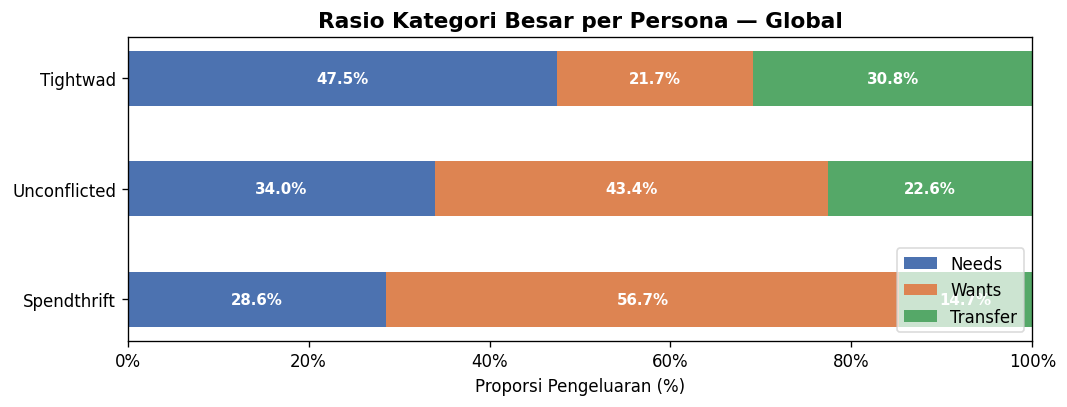

kategori_besar  Needs  Wants  Transfer
persona_dasar                         
Spendthrift      28.6   56.7      14.7
Unconflicted     34.0   43.4      22.6
Tightwad         47.5   21.7      30.8


In [12]:
# Merge debit dengan persona_dasar dari df_nas
df_persona = df_debit.merge(
    df_nas[['id_user', 'persona_dasar']],
    on='id_user', how='left'
)

# Agregasi: total nominal per persona × kategori_besar
ratio_global = (
    df_persona
    .groupby(['persona_dasar', 'kategori_besar'])['nominal']
    .sum()
    .reset_index()
)

# Hitung persentase dalam tiap persona (total = 100%)
ratio_global['pct'] = (
    ratio_global['nominal']
    / ratio_global.groupby('persona_dasar')['nominal'].transform('sum')
    * 100
)

# Pivot: baris = persona, kolom = kategori_besar
PERSONA_ORDER  = ['Spendthrift', 'Unconflicted', 'Tightwad']
KAT_BESAR_ORDER = ['Needs', 'Wants', 'Transfer']
COLORS          = {'Needs': '#4C72B0', 'Wants': '#DD8452', 'Transfer': '#55A868'}

pivot_global = (
    ratio_global
    .pivot(index='persona_dasar', columns='kategori_besar', values='pct')
    .reindex(index=PERSONA_ORDER, columns=KAT_BESAR_ORDER)
    .fillna(0)
)

# Plot stacked horizontal bar
fig, ax = plt.subplots(figsize=(9, 3.5))

left = [0] * len(PERSONA_ORDER)
for kat in KAT_BESAR_ORDER:
    vals = pivot_global[kat].values
    bars = ax.barh(PERSONA_ORDER, vals, left=left,
                   color=COLORS[kat], label=kat, height=0.5)
    for bar, val, lft in zip(bars, vals, left):
        if val >= 3:
            ax.text(
                lft + val / 2, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', ha='center', va='center',
                fontsize=9, color='white', fontweight='bold'
            )
    left = [l + v for l, v in zip(left, vals)]

ax.set_xlim(0, 100)
ax.set_xlabel('Proporsi Pengeluaran (%)')
ax.set_title('Rasio Kategori Besar per Persona — Global', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', framealpha=0.7)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.show()

print(pivot_global.round(1).to_string())

---
## 10. Rasio Kategori Besar per Persona per Segmen Pekerjaan

Breakdown yang sama dipecah per segmen demografi. Memverifikasi apakah pola Spendthrift→Wants berlaku konsisten di Mahasiswa, First Jobber, dan Profesional, atau ada perbedaan struktural antar segmen.

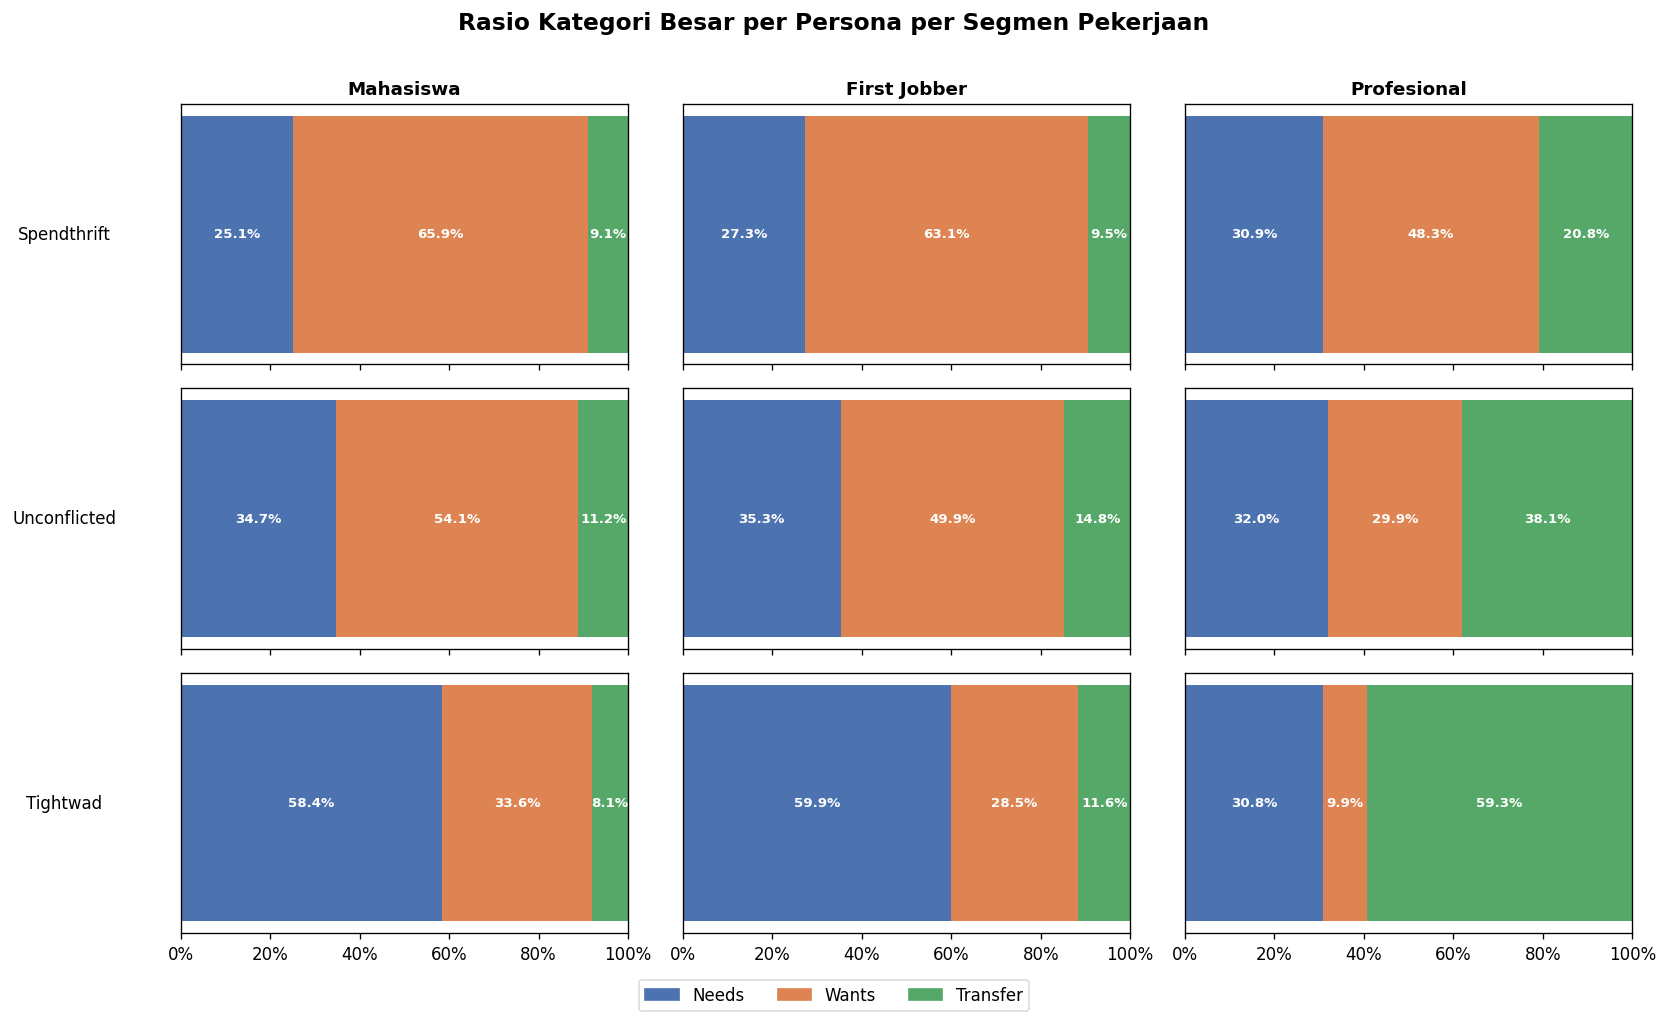

kategori_besar                  Needs  Wants  Transfer
segmen_demografi persona_dasar                        
Mahasiswa        Spendthrift     25.1   65.9       9.1
                 Unconflicted    34.7   54.1      11.2
                 Tightwad        58.4   33.6       8.1
First Jobber     Spendthrift     27.3   63.1       9.5
                 Unconflicted    35.3   49.9      14.8
                 Tightwad        59.9   28.5      11.6
Profesional      Spendthrift     30.9   48.3      20.8
                 Unconflicted    32.0   29.9      38.1
                 Tightwad        30.8    9.9      59.3


In [13]:
# Merge debit dengan persona + segmen
df_seg_persona = df_debit.merge(
    df_nas[['id_user', 'persona_dasar', 'segmen_demografi']],
    on='id_user', how='left'
)

# Agregasi: total nominal per segmen × persona × kategori_besar
ratio_seg = (
    df_seg_persona
    .groupby(['segmen_demografi', 'persona_dasar', 'kategori_besar'])['nominal']
    .sum()
    .reset_index()
)

# Persentase dalam tiap segmen × persona
ratio_seg['pct'] = (
    ratio_seg['nominal']
    / ratio_seg.groupby(['segmen_demografi', 'persona_dasar'])['nominal'].transform('sum')
    * 100
)

SEGMEN_ORDER = ['Mahasiswa', 'First Jobber', 'Profesional']

# Grid 3 kolom (segmen) × 3 baris (persona)
fig, axes = plt.subplots(
    nrows=3, ncols=3,
    figsize=(14, 8),
    sharey=False, sharex=True
)
fig.suptitle(
    'Rasio Kategori Besar per Persona per Segmen Pekerjaan',
    fontsize=14, fontweight='bold', y=1.01
)

for col_idx, segmen in enumerate(SEGMEN_ORDER):
    for row_idx, persona in enumerate(PERSONA_ORDER):
        ax = axes[row_idx][col_idx]

        subset = ratio_seg[
            (ratio_seg['segmen_demografi'] == segmen) &
            (ratio_seg['persona_dasar']    == persona)
        ].set_index('kategori_besar')['pct'].reindex(KAT_BESAR_ORDER).fillna(0)

        left = 0
        for kat in KAT_BESAR_ORDER:
            val = subset[kat]
            ax.barh([0], [val], left=left,
                    color=COLORS[kat], label=kat if (row_idx == 0 and col_idx == 0) else '_',
                    height=0.5)
            if val >= 4:
                ax.text(
                    left + val / 2, 0,
                    f'{val:.1f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold'
                )
            left += val

        ax.set_xlim(0, 100)
        ax.set_yticks([])
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

        # Header kolom (segmen) — hanya baris pertama
        if row_idx == 0:
            ax.set_title(segmen, fontsize=11, fontweight='bold')

        # Label baris (persona) — hanya kolom pertama
        if col_idx == 0:
            ax.set_ylabel(persona, fontsize=10, rotation=0,
                          labelpad=70, va='center')

fig.legend(
    handles=[
        plt.Rectangle((0,0),1,1, color=COLORS[k]) for k in KAT_BESAR_ORDER
    ],
    labels=KAT_BESAR_ORDER,
    loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.04),
    framealpha=0.7, fontsize=10
)

plt.tight_layout()
plt.show()

# Tabel ringkasan numerik
tbl = (
    ratio_seg
    .pivot_table(
        index=['segmen_demografi', 'persona_dasar'],
        columns='kategori_besar',
        values='pct'
    )
    .reindex(index=pd.MultiIndex.from_product([SEGMEN_ORDER, PERSONA_ORDER],
                                               names=['segmen_demografi', 'persona_dasar']),
             columns=KAT_BESAR_ORDER)
    .round(1)
)
print(tbl.to_string())